In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: '@rpath/libomp.dylib'\n  Referenced from: '/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib'\n  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/lib/libomp.dylib' (no such file)"]


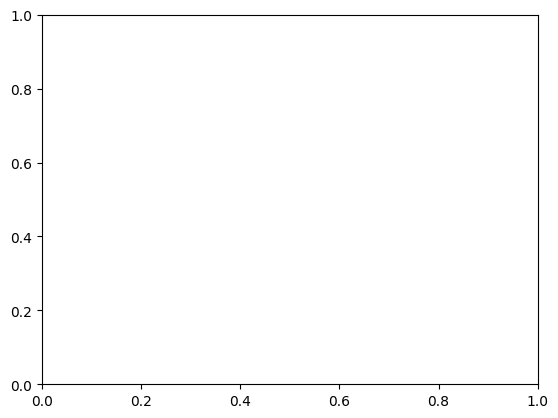

In [265]:
sns.set_palette('mako')
plt.ticklabel_format(style='plain', axis='y')
# pd.set_option('display.max_rows', None)

In [266]:
stack_df = pd.read_csv('../../Feature Engineering/resources/stack_overflowcsv.csv')

In [267]:
stack_df.isna().sum()

SurveyDate                      0
FormalEducation                 0
ConvertedSalary               334
Hobby                           0
Country                         0
StackOverflowJobsRecommend    512
VersionControl                  0
Age                             0
Years Experience                0
Gender                        306
RawSalary                     334
dtype: int64

In [268]:
stack_df.nunique()

SurveyDate                    997
FormalEducation                 9
ConvertedSalary               446
Hobby                           2
Country                        10
StackOverflowJobsRecommend     11
VersionControl                 39
Age                            57
Years Experience               25
Gender                          8
RawSalary                     515
dtype: int64

In [269]:
stack_df.head()

,SurveyDate,FormalEducation,ConvertedSalary,Hobby,Country,StackOverflowJobsRecommend,VersionControl,Age,Years Experience,Gender,RawSalary
0,2/28/18 20:20,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,Yes,South Africa,NaN,Git,21,13,Male,NaN
1,6/28/18 13:26,Bachelor's degree (BA. BS. B.Eng.. etc.),70841.0,Yes,Sweeden,7.0,Git;Subversion,38,9,Male,"70,841.00"
2,6/6/18 3:37,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,No,Sweeden,8.0,Git,45,11,NaN,NaN
3,5/9/18 1:06,Some college/university study without earning ...,21426.0,Yes,Sweeden,NaN,Zip file back-ups,46,12,Male,"21,426.00"
4,4/12/18 22:41,Bachelor's degree (BA. BS. B.Eng.. etc.),41671.0,Yes,UK,8.0,Git,39,7,Male,"£41,671.00"


In [270]:
stack_df

,SurveyDate,FormalEducation,ConvertedSalary,Hobby,Country,StackOverflowJobsRecommend,VersionControl,Age,Years Experience,Gender,RawSalary
0,2/28/18 20:20,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,Yes,South Africa,NaN,Git,21,13,Male,NaN
1,6/28/18 13:26,Bachelor's degree (BA. BS. B.Eng.. etc.),70841.0,Yes,Sweeden,7.0,Git;Subversion,38,9,Male,"70,841.00"
2,6/6/18 3:37,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,No,Sweeden,8.0,Git,45,11,NaN,NaN
3,5/9/18 1:06,Some college/university study without earning ...,21426.0,Yes,Sweeden,NaN,Zip file back-ups,46,12,Male,"21,426.00"
4,4/12/18 22:41,Bachelor's degree (BA. BS. B.Eng.. etc.),41671.0,Yes,UK,8.0,Git,39,7,Male,"£41,671.00"
...,...,...,...,...,...,...,...,...,...,...,...
994,10/19/18 13:50,Some college/university study without earning ...,NaN,Yes,France,NaN,Subversion,45,10,Male,NaN
995,4/14/18 15:31,Bachelor's degree (BA. BS. B.Eng.. etc.),58746.0,No,Spain,8.0,Git,27,16,Male,"58,746.00"
996,3/21/18 6:34,Bachelor's degree (BA. BS. B.Eng.. etc.),55000.0,Yes,USA,NaN,Git,54,16,Male,"$55,000.00"
997,2/5/18 20:01,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,Yes,Sweeden,NaN,Git;Subversion,23,9,NaN,NaN


In [271]:
stack_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SurveyDate                  999 non-null    str    
 1   FormalEducation             999 non-null    str    
 2   ConvertedSalary             665 non-null    float64
 3   Hobby                       999 non-null    str    
 4   Country                     999 non-null    str    
 5   StackOverflowJobsRecommend  487 non-null    float64
 6   VersionControl              999 non-null    str    
 7   Age                         999 non-null    int64  
 8   Years Experience            999 non-null    int64  
 9   Gender                      693 non-null    str    
 10  RawSalary                   665 non-null    str    
dtypes: float64(2), int64(2), str(7)
memory usage: 173.4 KB


In [272]:
stack_df.dtypes

SurveyDate                        str
FormalEducation                   str
ConvertedSalary               float64
Hobby                             str
Country                           str
StackOverflowJobsRecommend    float64
VersionControl                    str
Age                             int64
Years Experience                int64
Gender                            str
RawSalary                         str
dtype: object

In [273]:
stack_df.isna().sum()

SurveyDate                      0
FormalEducation                 0
ConvertedSalary               334
Hobby                           0
Country                         0
StackOverflowJobsRecommend    512
VersionControl                  0
Age                             0
Years Experience                0
Gender                        306
RawSalary                     334
dtype: int64

In [274]:
stack_df.nunique()

SurveyDate                    997
FormalEducation                 9
ConvertedSalary               446
Hobby                           2
Country                        10
StackOverflowJobsRecommend     11
VersionControl                 39
Age                            57
Years Experience               25
Gender                          8
RawSalary                     515
dtype: int64

<Axes: >

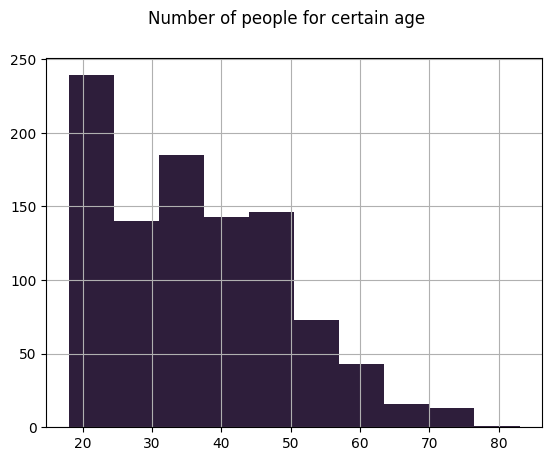

In [275]:
plt.suptitle("Number of people for certain age")
stack_df['Age'].hist()

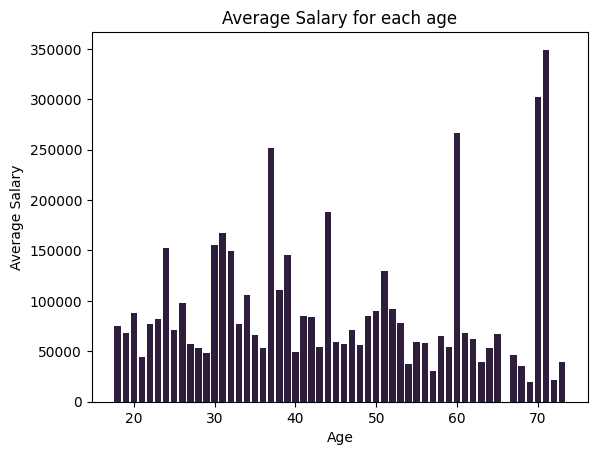

In [276]:
age_salary = stack_df.groupby('Age')['ConvertedSalary'].mean()

plt.bar(age_salary.index, age_salary.values)
plt.title("Average Salary for each age")
plt.ylabel("Average Salary")
plt.xlabel("Age")
plt.show()

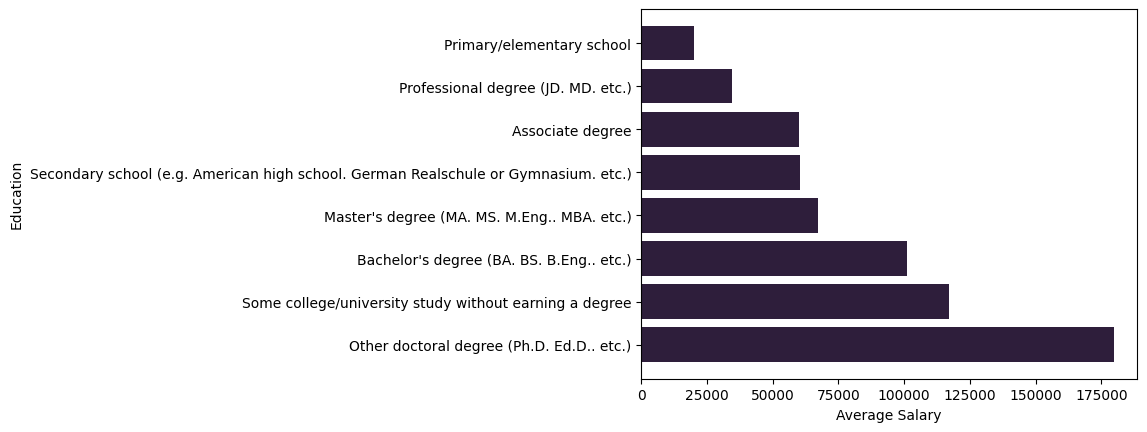

In [277]:
formal_edu = stack_df.groupby('FormalEducation')['ConvertedSalary'].mean().sort_values(ascending=False)

plt.barh(formal_edu.index, formal_edu.values)
plt.xlabel("Average Salary")
plt.ylabel("Education")
plt.show()

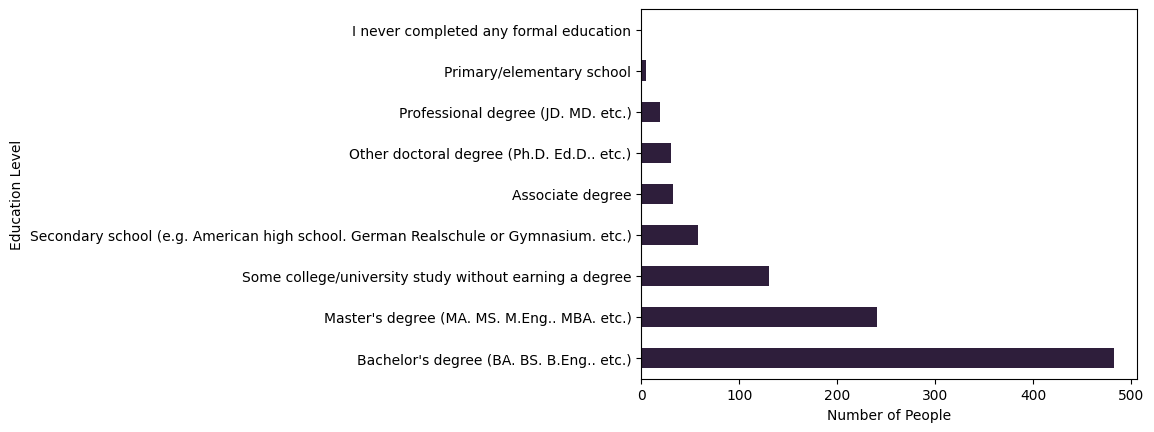

In [278]:
stack_df['FormalEducation'].value_counts().plot(kind='barh')
plt.ylabel("Education Level")
plt.xlabel("Number of People")
plt.show()

f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


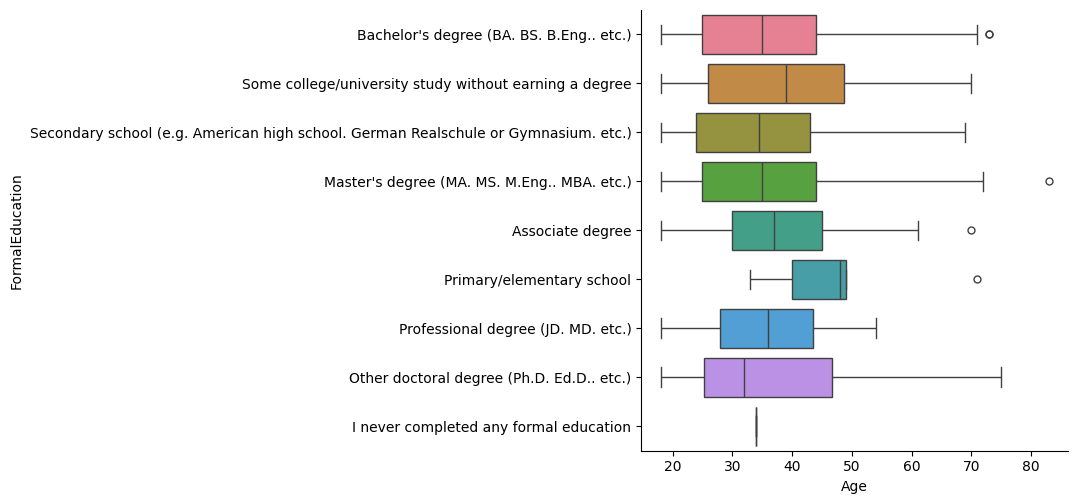

In [279]:
sns.catplot(data=stack_df,x='Age',kind='box',hue='FormalEducation',y='FormalEducation')

In [280]:
stack_df.isna().sum()

SurveyDate                      0
FormalEducation                 0
ConvertedSalary               334
Hobby                           0
Country                         0
StackOverflowJobsRecommend    512
VersionControl                  0
Age                             0
Years Experience                0
Gender                        306
RawSalary                     334
dtype: int64

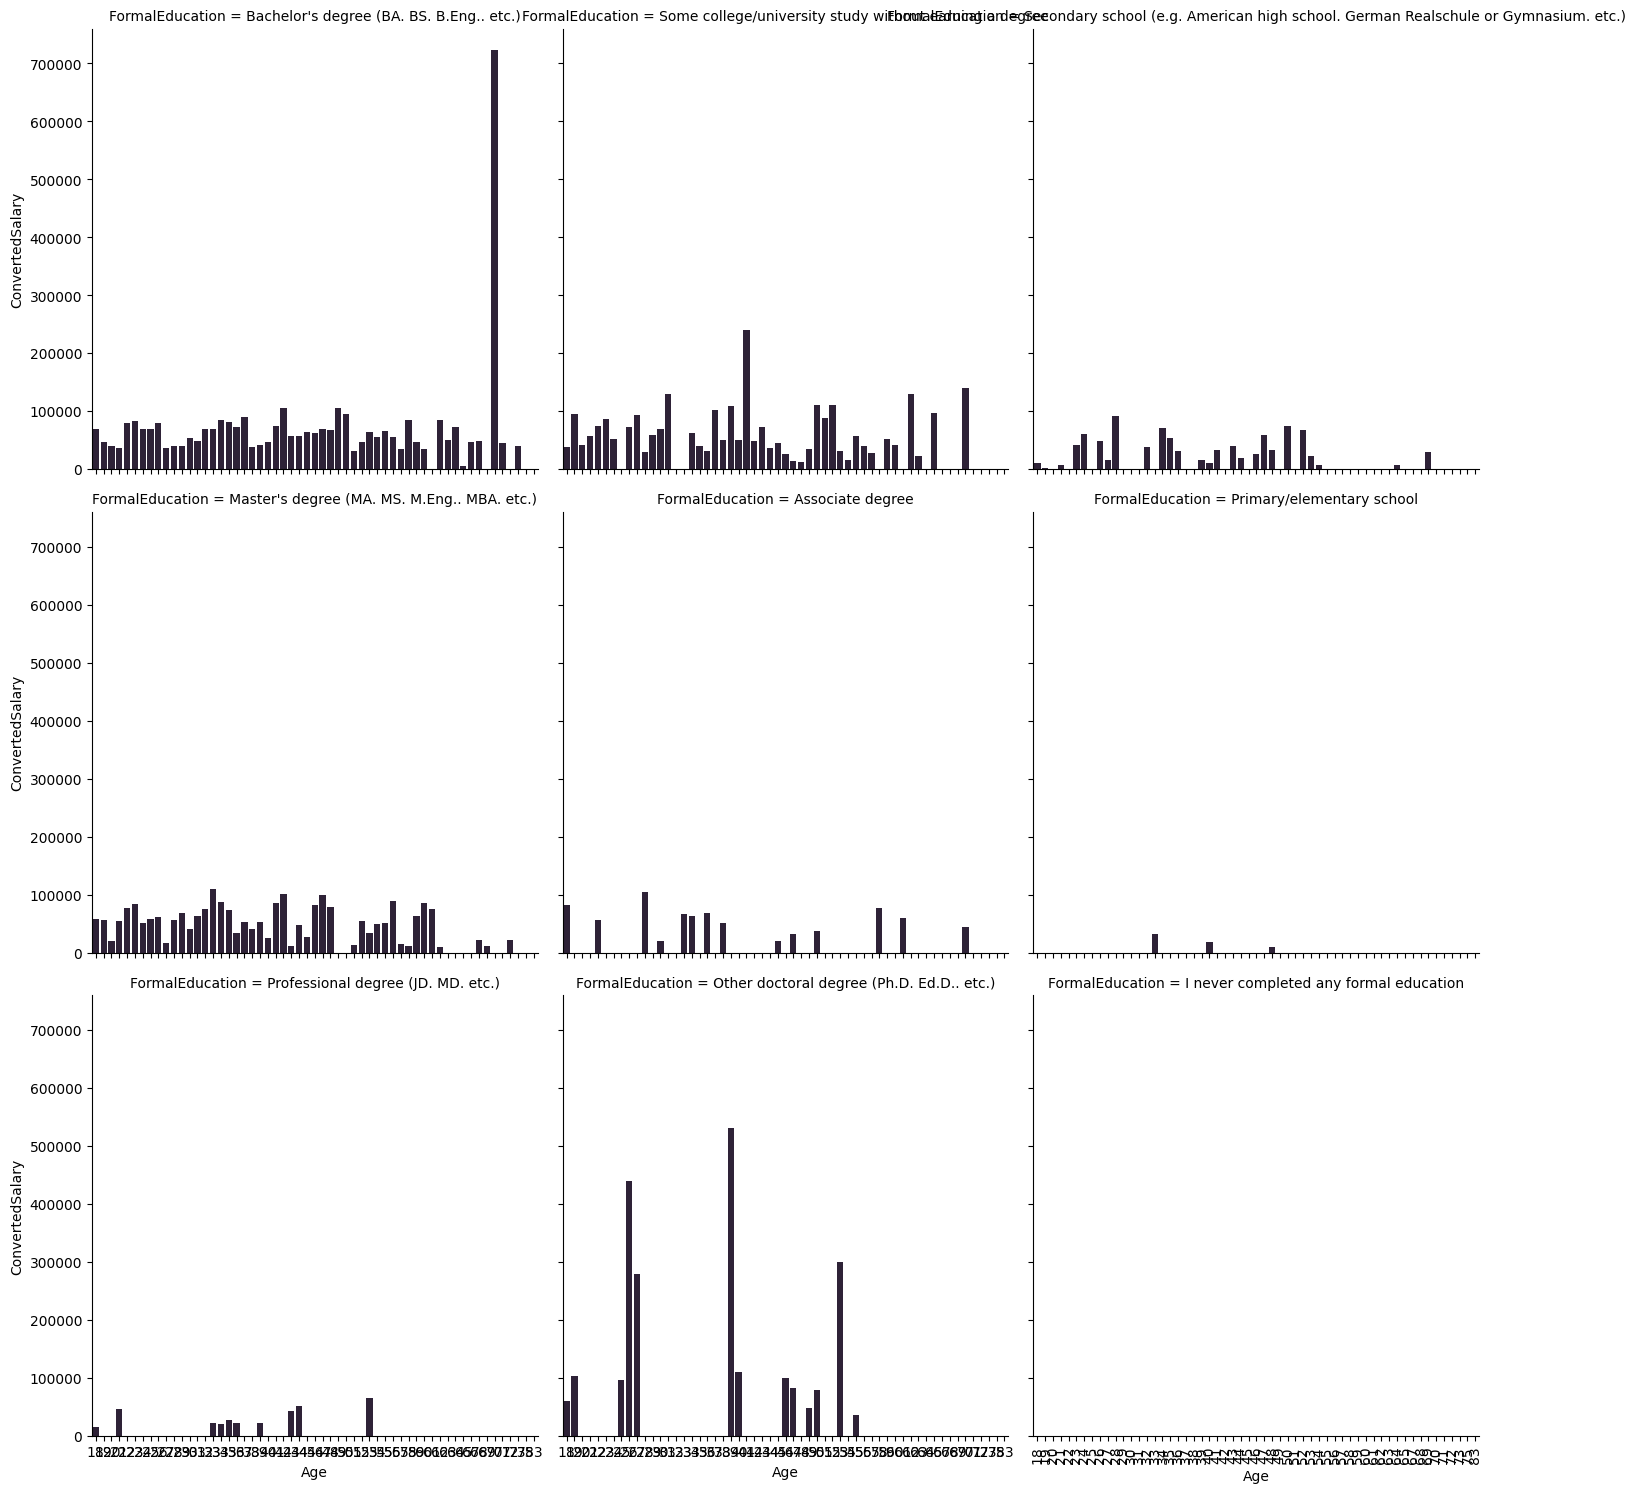

In [281]:
sns.catplot(
    x = 'Age',
    y = 'ConvertedSalary',
    data = stack_df , 
    kind = 'bar',
    col = 'FormalEducation',
    col_wrap = 3 ,
    errorbar = None,
    estimator= np.median
)
plt.xticks(rotation=90)

plt.show()

<Figure size 3000x1000 with 0 Axes>

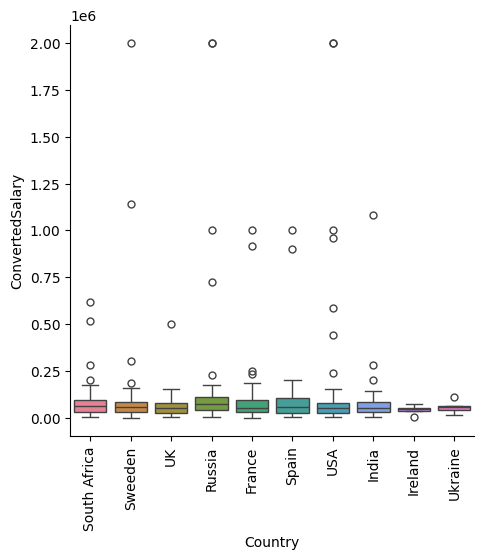

In [282]:
plt.figure(figsize=(30, 10)) 

sns.catplot(
    y='ConvertedSalary',
    x='Country',
    kind='box',
    data = stack_df,
    hue = 'Country',
    estimator= np.median
)

plt.xticks(rotation=90)
plt.show()

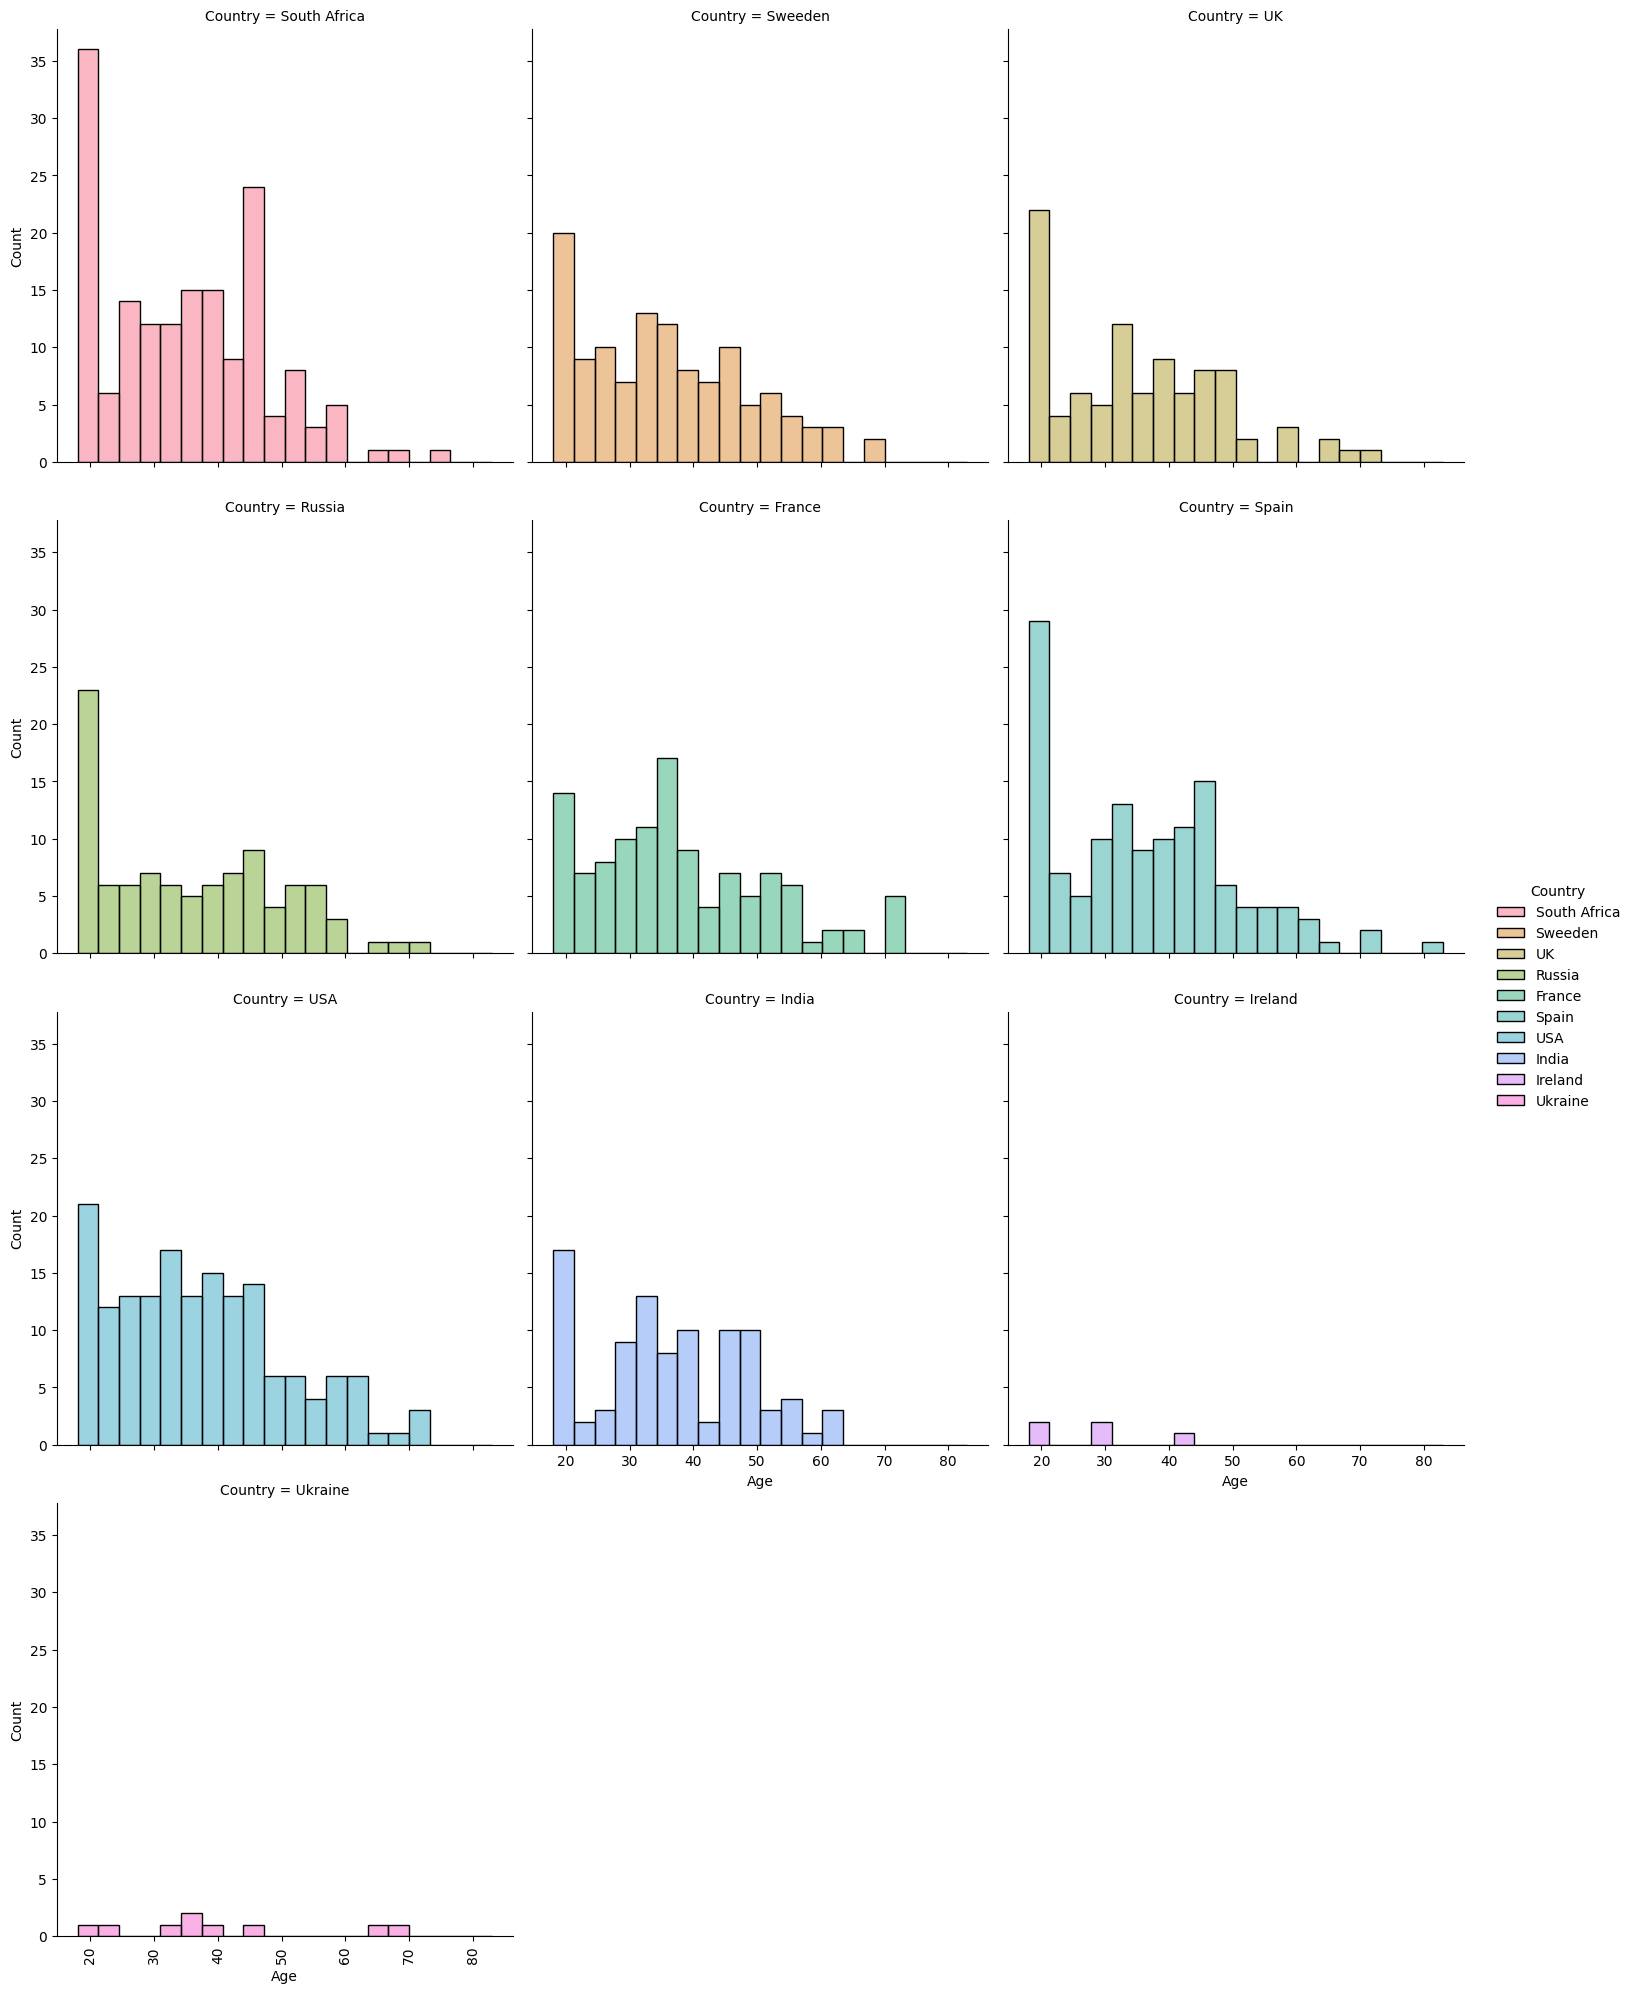

In [283]:
ax = sns.displot(
    x='Age',
    data=stack_df,
    col='Country',
    col_wrap=3,
    bins=20,
    hue='Country',
)

plt.xticks(rotation=90)
plt.show()

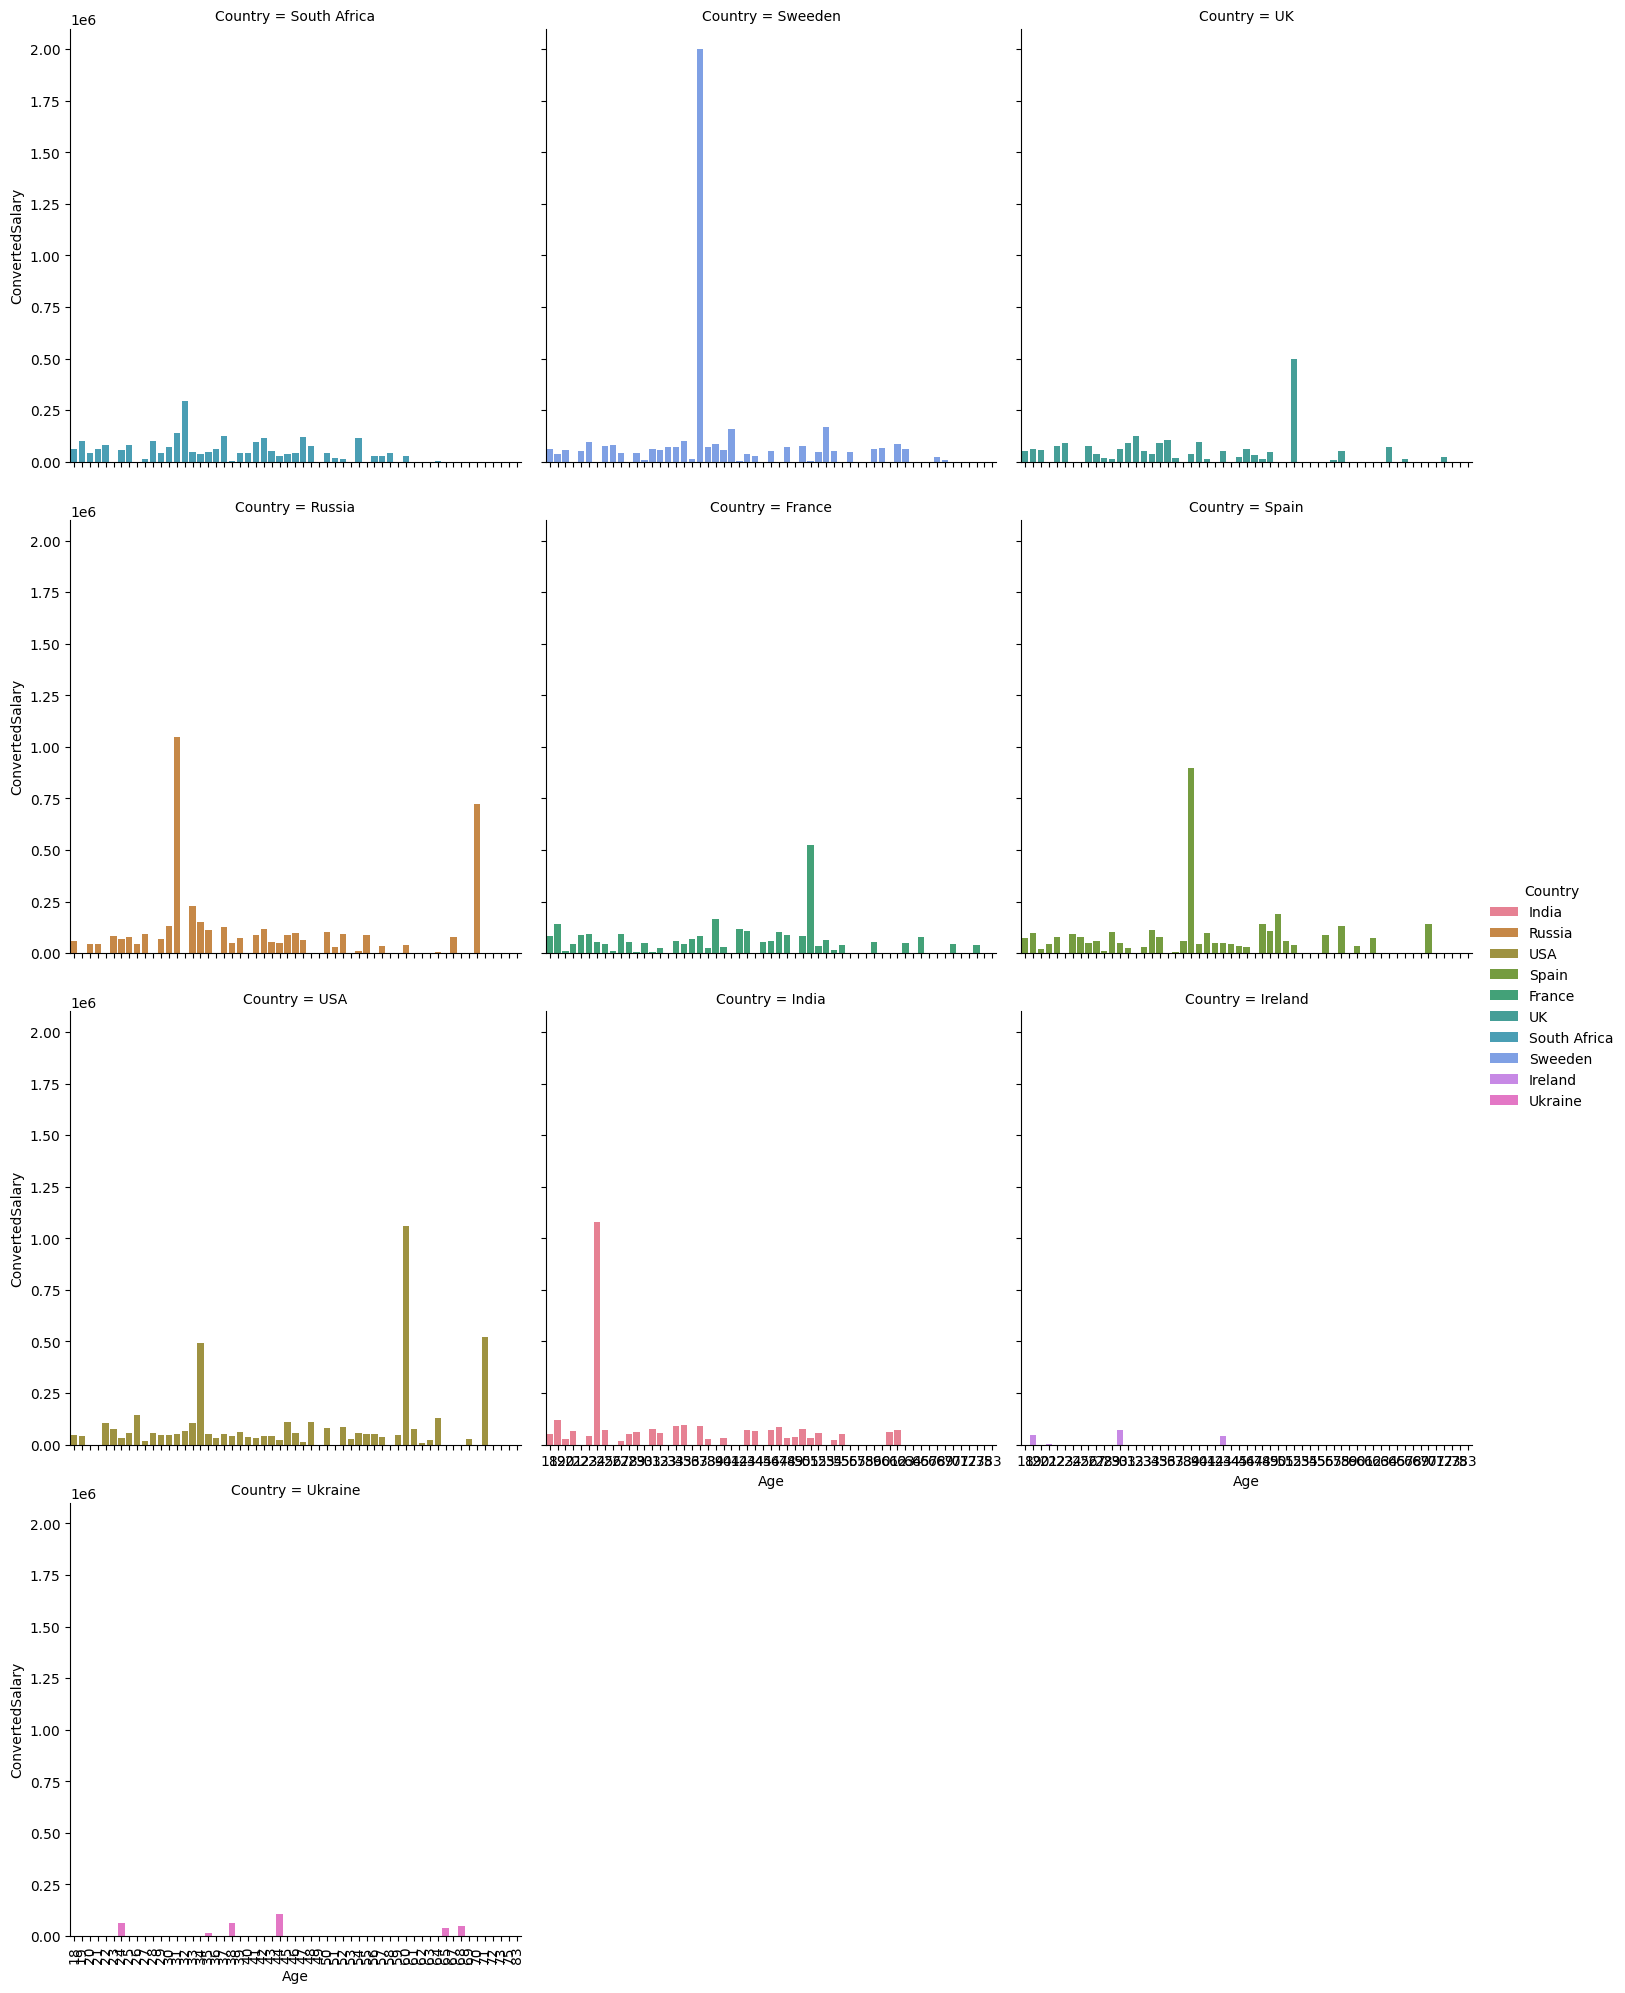

In [284]:
ax = sns.catplot(
    x='Age',
    y='ConvertedSalary',
    kind='bar',
    data=stack_df,
    col='Country',
    col_wrap=3,
    hue='Country',
    errorbar = None,
    estimator= np.median
)

plt.xticks(rotation=90)
plt.show()

In [285]:
stack_df['AgeBand'] = pd.cut(stack_df['Age'],bins=10)

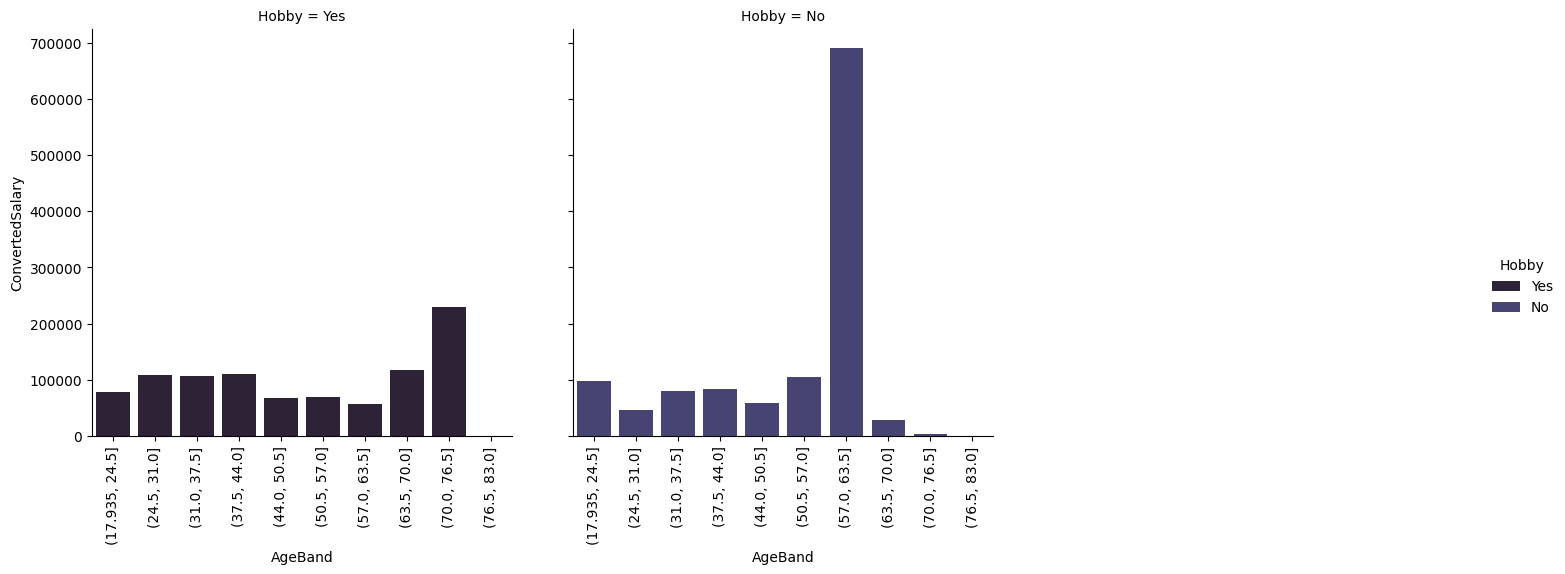

In [286]:
ax = sns.catplot(
    x='AgeBand',
    y='ConvertedSalary',
    kind='bar',
    data=stack_df,
    col="Hobby",
    col_wrap=3,
    hue='Hobby',
    errorbar=None
)

ax.set_xticklabels(rotation=90)
plt.show()

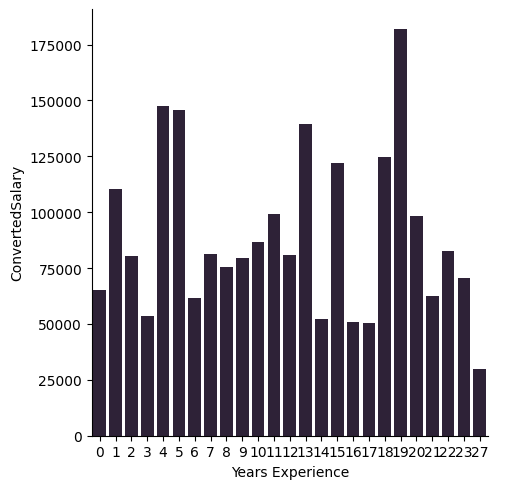

In [287]:
sns.catplot(
    x='Years Experience',
    y='ConvertedSalary',
    data=stack_df,
    kind='bar',
    errorbar=None
)

In [288]:
stack_df['Gender'].unique()

<ArrowStringArray>
[                                                                     'Male',
                                                                         nan,
                                                                    'Female',
 'Female;Male;Transgender;Non-binary. genderqueer. or gender non-conforming',
                                                               'Female;Male',
                    'Male;Non-binary. genderqueer. or gender non-conforming',
                         'Non-binary. genderqueer. or gender non-conforming',
                                                               'Transgender',
                                                        'Female;Transgender']
Length: 9, dtype: str

In [289]:
stack_df['Gender'] = stack_df['Gender'].str.extract(r'^(Male|Female|Transgender)')

In [290]:
stack_df['Gender'].unique()

<ArrowStringArray>
['Male', nan, 'Female', 'Transgender']
Length: 4, dtype: str

In [291]:
# stack_df = stack_df.dropna(stack_df['nan'])

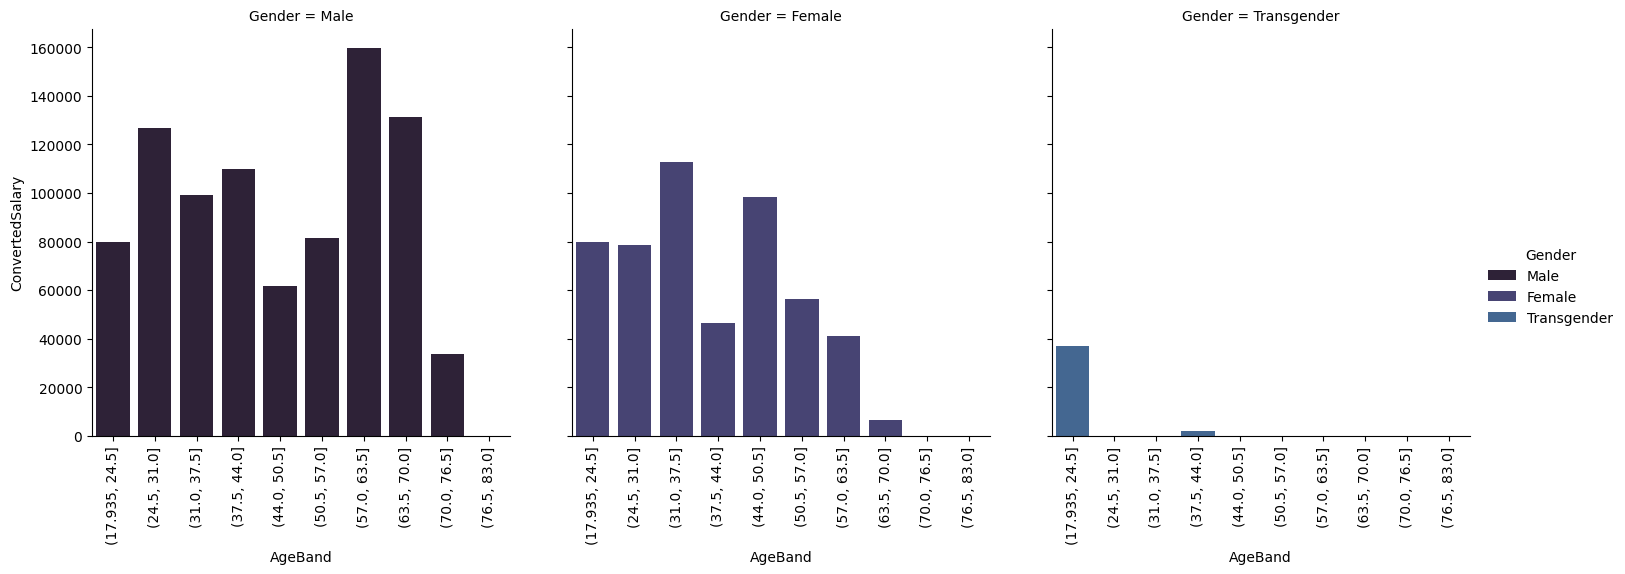

In [292]:
ax = sns.catplot(
    x='AgeBand',
    y='ConvertedSalary',
    data=stack_df,
    kind='bar',
    errorbar=None,
    col='Gender',
    hue='Gender',
    col_wrap = 3
)
ax.set_xticklabels(rotation=90)
plt.show()

In [293]:
stack_df['ConvertedSalary'] = pd.to_numeric(stack_df['ConvertedSalary'], errors='coerce')

In [294]:
print(stack_df['ConvertedSalary'])

0            NaN
1        70841.0
2            NaN
3        21426.0
4        41671.0
         ...    
994          NaN
995      58746.0
996      55000.0
997          NaN
998    1000000.0
Name: ConvertedSalary, Length: 999, dtype: float64


In [295]:

stack_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   SurveyDate                  999 non-null    str     
 1   FormalEducation             999 non-null    str     
 2   ConvertedSalary             665 non-null    float64 
 3   Hobby                       999 non-null    str     
 4   Country                     999 non-null    str     
 5   StackOverflowJobsRecommend  487 non-null    float64 
 6   VersionControl              999 non-null    str     
 7   Age                         999 non-null    int64   
 8   Years Experience            999 non-null    int64   
 9   Gender                      692 non-null    str     
 10  RawSalary                   665 non-null    str     
 11  AgeBand                     999 non-null    category
dtypes: category(1), float64(2), int64(2), str(7)
memory usage: 174.4 KB


In [296]:
stack_df.isna().sum()

SurveyDate                      0
FormalEducation                 0
ConvertedSalary               334
Hobby                           0
Country                         0
StackOverflowJobsRecommend    512
VersionControl                  0
Age                             0
Years Experience                0
Gender                        307
RawSalary                     334
AgeBand                         0
dtype: int64

In [297]:
df = stack_df

In [298]:

df['ConvertedSalary'] = df.groupby(
['Country','FormalEducation','Years Experience','StackOverflowJobsRecommend']
)['ConvertedSalary'].transform(lambda x: x.fillna(x.median()))

df['ConvertedSalary'] = df.groupby(
['Country','FormalEducation','Years Experience']
)['ConvertedSalary'].transform(lambda x: x.fillna(x.median()))


df['ConvertedSalary'] = df.groupby(
['Country','FormalEducation']
)['ConvertedSalary'].transform(lambda x: x.fillna(x.median()))


df['ConvertedSalary'] = df.groupby(
['Country']
)['ConvertedSalary'].transform(lambda x: x.fillna(x.median()))


df['ConvertedSalary'] = df['ConvertedSalary'].fillna(df['ConvertedSalary'].median())

In [299]:
df['ConvertedSalary']

0       65000.0
1       70841.0
2      185000.0
3       66000.0
4       41671.0
         ...   
994     95500.0
995     58746.0
996     72044.5
997     14089.0
998     39164.0
Name: ConvertedSalary, Length: 999, dtype: float64

# Removing Outliers

In [300]:
mean = df['ConvertedSalary'].mean()
std = df['ConvertedSalary'].std()

cut_off = std * 3

lower , upper = mean - cut_off , mean + cut_off

df = df[(df['ConvertedSalary'] < upper) & (df['ConvertedSalary'] > lower)]

# Standardizing Converted Salary

<Axes: >

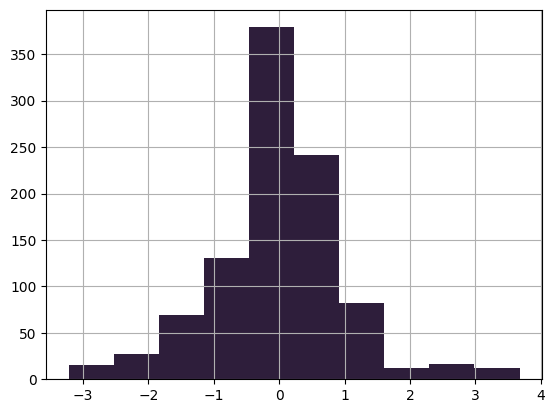

In [301]:
log = PowerTransformer()
log.fit(df[['ConvertedSalary']])

df['log_ConvertedSalary'] = log.transform(df[["ConvertedSalary"]])

df['log_ConvertedSalary'].hist()

In [302]:
df.isna().sum()

SurveyDate                      0
FormalEducation                 0
ConvertedSalary                 0
Hobby                           0
Country                         0
StackOverflowJobsRecommend    509
VersionControl                  0
Age                             0
Years Experience                0
Gender                        302
RawSalary                     333
AgeBand                         0
log_ConvertedSalary             0
dtype: int64

In [303]:
drop_col = ['StackOverflowJobsRecommend','Gender','RawSalary','SurveyDate','AgeBand','VersionControl','ConvertedSalary']

In [304]:
df = df.drop(columns=drop_col)

In [305]:
df.columns

Index(['FormalEducation', 'Hobby', 'Country', 'Age', 'Years Experience',
       'log_ConvertedSalary'],
      dtype='str')

In [306]:
df.head(20)

,FormalEducation,Hobby,Country,Age,Years Experience,log_ConvertedSalary
0,Bachelor's degree (BA. BS. B.Eng.. etc.),Yes,South Africa,21,13,0.173180
1,Bachelor's degree (BA. BS. B.Eng.. etc.),Yes,Sweeden,38,9,0.292232
2,Bachelor's degree (BA. BS. B.Eng.. etc.),No,Sweeden,45,11,1.844375
3,Some college/university study without earning ...,Yes,Sweeden,46,12,0.194085
4,Bachelor's degree (BA. BS. B.Eng.. etc.),Yes,UK,39,7,-0.396439
5,Some college/university study without earning ...,Yes,Russia,39,2,1.090446
6,Bachelor's degree (BA. BS. B.Eng.. etc.),Yes,UK,34,11,-0.047799
7,Some college/university study without earning ...,Yes,France,24,2,2.427924
8,Bachelor's degree (BA. BS. B.Eng.. etc.),No,South Africa,23,17,0.157437
9,Secondary school (e.g. American high school. G...,No,France,36,2,0.219657


In [307]:
encoder = OneHotEncoder(sparse_output=False)

In [308]:
columns = ['FormalEducation','Country']

In [309]:
df.dtypes

FormalEducation            str
Hobby                      str
Country                    str
Age                      int64
Years Experience         int64
log_ConvertedSalary    float64
dtype: object

In [310]:
for col in columns:
    df = pd.get_dummies(df,columns=[col],prefix={col[0]})

In [311]:
df.columns

Index(['Hobby', 'Age', 'Years Experience', 'log_ConvertedSalary',
       'F_Associate degree', 'F_Bachelor's degree (BA. BS. B.Eng.. etc.)',
       'F_I never completed any formal education',
       'F_Master's degree (MA. MS. M.Eng.. MBA. etc.)',
       'F_Other doctoral degree (Ph.D. Ed.D.. etc.)',
       'F_Primary/elementary school', 'F_Professional degree (JD. MD. etc.)',
       'F_Secondary school (e.g. American high school. German Realschule or Gymnasium. etc.)',
       'F_Some college/university study without earning a degree', 'C_France',
       'C_India', 'C_Ireland', 'C_Russia', 'C_South Africa', 'C_Spain',
       'C_Sweeden', 'C_UK', 'C_USA', 'C_Ukraine'],
      dtype='str')

In [312]:
le = LabelEncoder()
df['Hobby'] = le.fit_transform(df['Hobby'])

In [313]:
df.head()

,Hobby,Age,Years Experience,log_ConvertedSalary,F_Associate degree,F_Bachelor's degree (BA. BS. B.Eng.. etc.),F_I never completed any formal education,F_Master's degree (MA. MS. M.Eng.. MBA. etc.),F_Other doctoral degree (Ph.D. Ed.D.. etc.),F_Primary/elementary school,...,C_France,C_India,C_Ireland,C_Russia,C_South Africa,C_Spain,C_Sweeden,C_UK,C_USA,C_Ukraine
0,1,21,13,0.173180,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,1,38,9,0.292232,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,0,45,11,1.844375,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,1,46,12,0.194085,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,1,39,7,-0.396439,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


# Creating a feature

In [315]:
df['experience_per_age'] = df['Years Experience'] / df['Age']

In [316]:
feature = df.drop('log_ConvertedSalary',axis=1).values
target = df['log_ConvertedSalary'].values

In [317]:
X_train, X_test, y_train, y_test = train_test_split(feature,target, test_size=0.3,random_state=1)

# What is MSE?
- Mean Squared Error (MSE) measures the average squared difference between predicted and actual values:
- MSE=1n∑i=1n(yi−y^i)2MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2MSE=n1​i=1∑n​(yi​−y^​i​)2

- Lower MSE = better model

# GridSearchCV vs RandomizedSearchCV

### GridSearchCV
- Exhaustively tries every possible combination in the parameter grid.
- ✅ Guaranteed to find the best combination within the grid
- ❌ Very slow — 3,000 combinations × 5 folds = 15,000 model fits
- ❌ Computationally expensive for large grids
### RandomizedSearchCV

- Randomly samples n_iter combinations from the grid.
- ✅ Much faster — you control how many combinations to try
- ✅ Can cover a wider search space (supports distributions, not just lists)
- ❌ Not guaranteed to find the absolute best combination

# Descision Tree

In [318]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_leaf_nodes': [None, 10, 20, 50, 100],
    'min_impurity_decrease': [0.0, 0.01, 0.05, 0.1]
}

dt = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train,y_train)


f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
57600 fits failed out of a total of 230400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
57600 fits failed with the following error:
Traceback (most recent call last):
  File "f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "f:\mubashir\Coding\Machine Learning\venv\Lib\site-pac

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'max_leaf_nodes': [None, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.

In [319]:
best_hyperparams = grid_search.best_params_
print("Best hyperparameters:\n" , best_hyperparams)

Best hyperparameters:
 {'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 20, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}


In [320]:
best_model = grid_search.best_estimator_

y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2:", test_r2)
print("Train R2:", train_r2)

Test R2: 0.22107671211124358
Train R2: 0.252799675926081


# Descision Tree Adaboost

In [321]:
adf_reg_dt = AdaBoostRegressor(
    estimator=best_model,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)

adf_reg_dt.fit(X_train, y_train)

y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2:", test_r2)
print("Train R2:", train_r2)



Test R2: 0.22107671211124358
Train R2: 0.252799675926081


# Desicion Tree Gradient boosting Regressor

In [322]:
gbt_dt = GradientBoostingRegressor(n_estimators=150,max_depth=16,random_state=1)

gbt_dt.fit(X_train, y_train)

y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2:", test_r2)
print("Train R2:", train_r2)



Test R2: 0.22107671211124358
Train R2: 0.252799675926081


# Ramdomised Search

In [323]:
random_search = RandomizedSearchCV(dt, param_grid, n_iter=100, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)

random_search.fit(X_train,y_train)

best_model = random_search.best_estimator_
print(best_model)

y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2:", test_r2)
print("Train R2:", train_r2)

DecisionTreeRegressor(max_leaf_nodes=10, min_samples_leaf=2, random_state=42)
Test R2: 0.21349781872990536
Train R2: 0.23170970485051334


f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
125 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "f:\mubashir\Coding\Machine Learning\venv\Lib\site-packages\s

# Random Forest

In [324]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
rf = RandomForestRegressor(random_state=1)


random_rf = RandomizedSearchCV(estimator=rf,param_distributions=param_grid,scoring='neg_mean_squared_error',cv=3,n_jobs=-1,verbose=1)
random_rf.fit(X_train,y_train)

best_model = random_rf.best_estimator_
print(best_model)

print(importance)
importance = best_model.feature_importances_

y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2:", test_r2)
print("Train R2:", train_r2)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                      min_samples_leaf=2, min_samples_split=5, n_estimators=300,
                      random_state=1)
[2.68492795e-02 2.37040254e-01 2.24512248e-01 1.31053381e-03
 3.83029648e-02 0.00000000e+00 3.29167653e-02 9.83646238e-02
 0.00000000e+00 3.37174083e-03 2.17467923e-02 3.21566284e-02
 2.88427103e-02 1.69743888e-02 8.13327995e-06 5.09833931e-02
 5.26802184e-02 2.46374858e-02 2.63292463e-02 1.31339650e-02
 6.91576030e-02 6.81025618e-04]
Test R2: 0.30626703750470874
Train R2: 0.7444151347896322


# XGB boost

In [ ]:

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
print(best_model)

y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2:", test_r2)
print("Train R2:", train_r2)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
Test R2: 0.24601489407358568
Train R2: 0.45511766824324973


# CV in XGB Boost

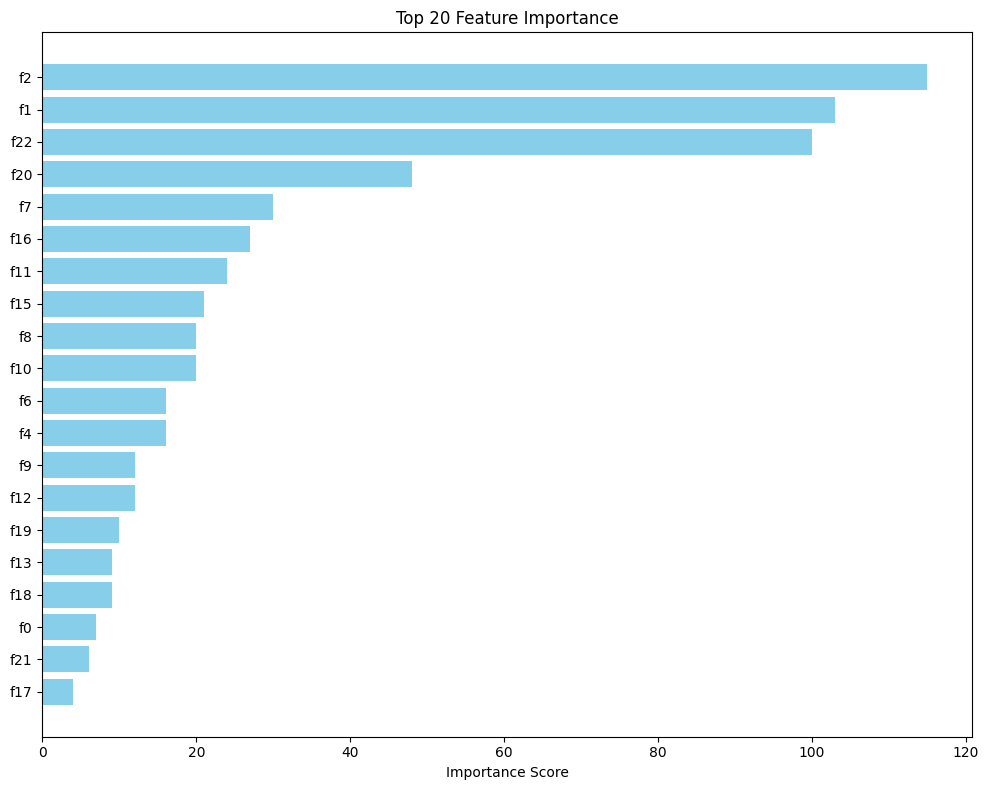

In [326]:

importance = best_model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

| Models   	| Descision Tree Regressor GridSearch 	| Descision Tree Regressor Randomised Search 	| Desicision Tree Adaboost 	| Random Forest 	| XGBRegressor 	|
|----------	|-------------------------------------	|--------------------------------------------	|--------------------------	|---------------	|--------------	|
| Test R2  	| 0.19923                             	| 0.216401                                   	| 0.199236                 	| 0.358500      	| 0.279021     	|
| Train R2 	| 0.21497                             	| 0.20333                                    	| 0.214970                 	| 0.7349888     	| 0.4164612    	|